In [1]:
import kagglehub

path = kagglehub.dataset_download("wannad1e/cropped-celeba")

print("Path to dataset files:", path)

/home/user/miniconda/envs/minus_face/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /path/to/celeba


In [2]:
images = "val"

In [3]:
import sys 
from minusface import MinusBackbone
model = MinusBackbone(mode='stage1')
import torch
ckpt_path = "../../../../minusface_stage1.pth"
model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))

<All keys matched successfully>

In [4]:
def preprocess_image(image_path, size=112):
    from PIL import Image
    from torchvision import transforms

    input_image = Image.open(image_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    input_tensor = preprocess(input_image)
    input_batch = input_tensor.unsqueeze(0)  # Create a mini-batch as expected by the model
    return input_batch

In [5]:
model = model.eval()
model = model.to('cuda')

In [6]:
import os
img_path = f"{images}/{os.listdir(images)[2342]}"

In [7]:
def get_another_image(df, img_name):
    row = df[df["img_name"] == img_name]
    if row.empty:
        return None
    id_val = row["id"].iloc[0]
    imgs = df[df["id"] == id_val]["img_name"].tolist()
    imgs = [x for x in imgs if x != img_name]
    return imgs[0] if imgs else None

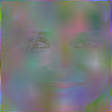

In [8]:
from PIL import Image
res = model(preprocess_image(img_path).to('cuda'))
shuffled = res[5].detach().cpu()[0].permute(1, 2, 0).numpy()
shuffled = (shuffled - shuffled.min()) / (shuffled.max() - shuffled.min())
shuffled = shuffled * 255
shuffled = shuffled.astype('uint8')
Image.fromarray(shuffled).save("shuffled.png")
Image.fromarray(shuffled)

In [9]:
from facenet_pytorch import InceptionResnetV1
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

teacher = InceptionResnetV1(pretrained='vggface2').eval().to(device)

student = InceptionResnetV1(pretrained='vggface2').to(device)
state = torch.load("student.pth", map_location=device)
student.load_state_dict(state)
student = student.eval()

In [10]:
import pandas as pd
df = pd.read_csv('/path/to/Identity_CelebA.txt', sep=' ')
df.columns = ["col0","img_name","id"]
another_img = get_another_image(df, img_path.replace("val/", ""))
img_path.replace("val/", ""), another_img 

('003571.jpg', '022099.jpg')

In [ ]:
sim = []
import numpy as np
with torch.no_grad(): 
    shuffled_features = student(preprocess_image("shuffled.png", size=160).to("cuda"))
    original_features = teacher(preprocess_image("/path/to/celeba_aligned/"+another_img).to("cuda"))
    sim.append(torch.nn.functional.cosine_similarity(shuffled_features, original_features).item())

for image_name in os.listdir(images): 
    with torch.no_grad(): 
        shuffled_features = student(preprocess_image("shuffled.png", size=160).to("cuda"))
        original_features = teacher(preprocess_image(img_path.replace(os.path.basename(img_path), image_name)).to("cuda"))
    sim.append(torch.nn.functional.cosine_similarity(shuffled_features, original_features).item())
    print(1-np.where(np.argsort(sim)==0)[0]/len(sim))

In [ ]:
# !ls /path/to/celeba/

In [ ]:
# training_ids = df_filtered.sample(n=5_000)["id"]
# training_images = df[df["id"].isin(training_ids)]

In [ ]:
# validation_images = df_filtered[~df_filtered["id"].isin(training_ids)]

In [ ]:
# len(training_images), len(validation_images) 

In [ ]:
# import os 
# os.makedirs("training", exist_ok=True)

In [ ]:
# for image_name in training_images["img_name"].tolist():
#     os.system(f"cp '/path/to/celeba_aligned/{image_name}' training/{image_name}")

In [ ]:
# os.makedirs("val", exist_ok=True)
# for image_name in validation_images["img_name"].tolist():
#     os.system(f"cp '/path/to/celeba_aligned/{image_name}' val/{image_name}")

In [1]:

import cv2
from insightface.app import FaceAnalysis
import torch

app = FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(160, 160))

/home/user/miniconda/envs/minus_face/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/user/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/user/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/user/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/user/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/user/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size

In [18]:
import os
training_images = os.listdir("val")

In [19]:
embeddings = []

In [ ]:
def get_faceid_embedding(sample):
    try:
        image = cv2.imread("val/" + sample["image_name"])
        faces = app.get(image)
        faceid_embeds = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
        return {"embedding": faceid_embeds} 
    except:
        return {"embedding": None}

In [21]:
from datasets import Dataset
ds = Dataset.from_dict({"image_name": training_images})

In [22]:
ds = ds.map(get_faceid_embedding, num_proc=100)

In [23]:
ds.save_to_disk("celeba_faceid_embeddings_val")

In [13]:
sum([1 for i in list(ds["embedding"]) if i is None]) 

14